<a href="https://colab.research.google.com/github/amydiab/analyse-emploi-senegal/blob/diabate/analyse_emploi_senegal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Introduction & contexte
2. Import des bibliothèques
3. Chargement des données
4. Analyse exploratoire
5. Visualisations
6. Conclusions & limites

# Analyse des Offres d'Emploi au Sénégal
**Source :** senjob.com & goafricaonline.com  
**Période :** Juillet 2024 — Avril 2026  
**Auteure :** Aminata Diabaté  
**Objectif :** Analyser les secteurs, compétences et tendances du marché de l'emploi Sénégalais

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

plt.style.use('seaborn-v0_8')
sns.set_palette("Greens_r")

In [35]:
df = pd.read_csv('dataset_final_propre.csv')
print(f"Nombre d'offres : {len(df)}")
print(f"Colonnes : {df.columns.tolist()}")
df.head()

Nombre d'offres : 4212
Colonnes : ['intitule_poste', 'ville', 'date_publication', 'mois', 'contrat', 'entreprise', 'source', 'secteur', 'competences', 'experience', 'exp_min', 'exp_max']


,intitule_poste,ville,date_publication,mois,contrat,entreprise,source,secteur,competences,experience,exp_min,exp_max
0,Agents distributeur,zone rurale,2026-04-10,2026-04-01,Non spécifié,Non spécifié,senjob.com,Non spécifié,"vente, finance, santé",Non spécifié,NaN,NaN
1,Stagiaire Rayonniste,Dakar,2026-04-09,2026-04-01,Non spécifié,Non spécifié,senjob.com,Non spécifié,vente,Non spécifié,NaN,NaN
2,Caissière,Dakar,2026-04-09,2026-04-01,Non spécifié,Non spécifié,senjob.com,Non spécifié,NaN,Non spécifié,NaN,NaN
3,Stagiaire IT,Dakar,2026-04-09,2026-04-01,Non spécifié,Non spécifié,senjob.com,Non spécifié,"finance, recrutement",Non spécifié,NaN,NaN
4,Managing Director Everllence Senegal,Dakar,2026-04-09,2026-04-01,Non spécifié,Non spécifié,senjob.com,Non spécifié,NaN,Non spécifié,NaN,NaN


In [37]:
regroupements = {
    'comptabilité': 'finance',
    'comptable': 'finance',
    'banque': 'finance',
    'analyse de données': 'data analyse',
    'collecte de données': 'data analyse',
    'traitement de données': 'data analyse',
    'marketing digital': 'marketing',
    'gestion des réseaux sociaux': 'marketing',
}
toutes_competences = toutes_competences.replace(regroupements)

In [38]:
regroupements = {
    'comptabilité': 'finance',
    'comptable': 'finance',
    'banque': 'finance',
    'analyse de données': 'data analyse',
    'collecte de données': 'data analyse',
    'traitement de données': 'data analyse',
    'visualisation': 'data analyse',
    'marketing digital': 'marketing',
    'gestion des réseaux sociaux': 'marketing',
    'relation commerciale': 'vente',
    'commercial': 'vente',
    'ressources humaines': 'rh',
    'développement web': 'programmation',
    "développement d'applications": 'programmation',
    "développement d'api": 'programmation',
    'transport': 'logistique',
}

a_supprimer = ['informatique', 'formation', 'Non spécifié']

def nettoyer_competences(texte):
    if pd.isna(texte):
        return ''
    comps = [c.strip().lower() for c in texte.split(',')]
    comps = [regroupements.get(c, c) for c in comps]
    comps = [c for c in comps if c not in a_supprimer and c != '']
    comps = list(dict.fromkeys(comps))
    return ', '.join(comps)

df['competences_clean'] = df['competences'].apply(nettoyer_competences)
print("Fait ! Aperçu :")
df[['competences', 'competences_clean']].head(10)

Fait ! Aperçu :


,competences,competences_clean
0,"vente, finance, santé","vente, finance, santé"
1,vente,vente
2,NaN,
3,"finance, recrutement","finance, recrutement"
4,NaN,
5,NaN,
6,"recrutement, rh","recrutement, rh"
7,"communication, finance","communication, finance"
8,"vente, finance, santé","vente, finance, santé"
9,"finance, rh, santé","finance, rh, santé"


In [39]:
df['competences'] = df['competences_clean']
df = df.drop(columns=['competences_clean'])
df.to_csv('dataset_final_propre.csv', index=False)
print("Fichier sauvegardé !")

Fichier sauvegardé !


In [41]:
toutes_competences[toutes_competences.str.contains('data|analyse', case=False)].value_counts()

,count
competences,
data analyse,858


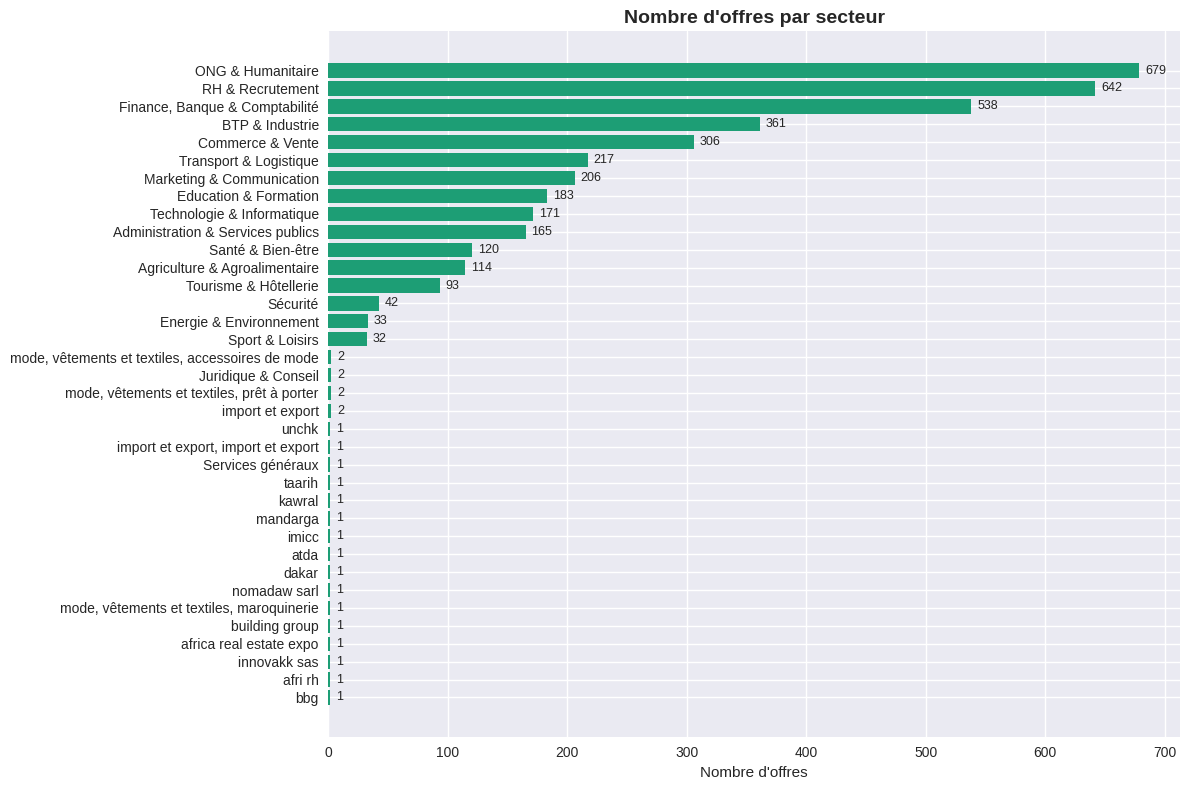

In [36]:
## 1. Nombre d'offres par secteur

secteur_count = df['secteur'].value_counts().dropna()
secteur_count = secteur_count[secteur_count.index != 'Non spécifié']

plt.figure(figsize=(12, 8))
bars = plt.barh(secteur_count.index, secteur_count.values, color='#1D9E75')
plt.xlabel("Nombre d'offres")
plt.title("Nombre d'offres par secteur", fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for bar, val in zip(bars, secteur_count.values):
    plt.text(val + 5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

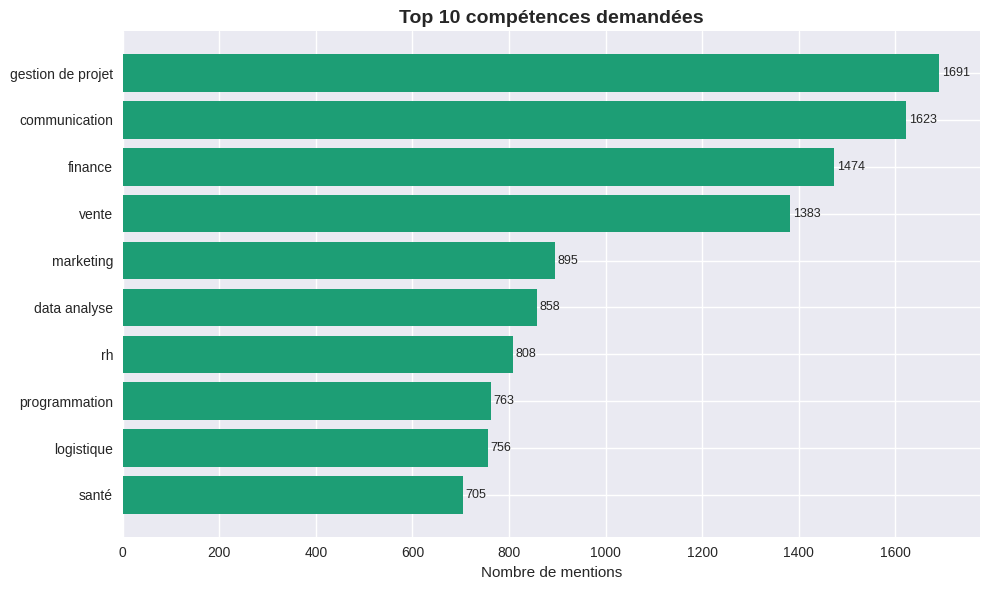

In [40]:
 ##2. Top 10 compétences demandées

competences_a_exclure = ['informatique', 'formation', 'recrutement', 'Non spécifié', '']

toutes_competences = df['competences'].dropna().str.split(',').explode().str.strip().str.lower()
toutes_competences = toutes_competences[~toutes_competences.isin(competences_a_exclure)]
top_comp = toutes_competences.value_counts().head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_comp.index, top_comp.values, color='#1D9E75')
plt.xlabel("Nombre de mentions")
plt.title("Top 10 compétences demandées", fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for bar, val in zip(bars, top_comp.values):
    plt.text(val + 5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

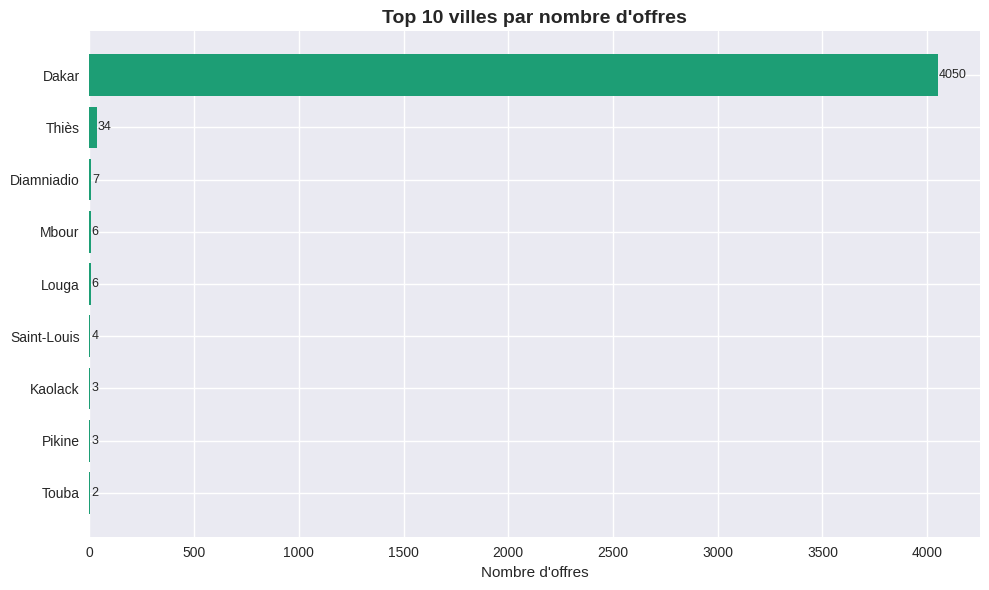

In [43]:
##3. Répartition géographique

ville_count = df['ville'].value_counts().dropna().head(10)
ville_count = ville_count[ville_count.index != 'Non spécifié']

plt.figure(figsize=(10, 6))
bars = plt.barh(ville_count.index, ville_count.values, color='#1D9E75')
plt.xlabel("Nombre d'offres")
plt.title("Top 10 villes par nombre d'offres", fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for bar, val in zip(bars, ville_count.values):
    plt.text(val + 5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

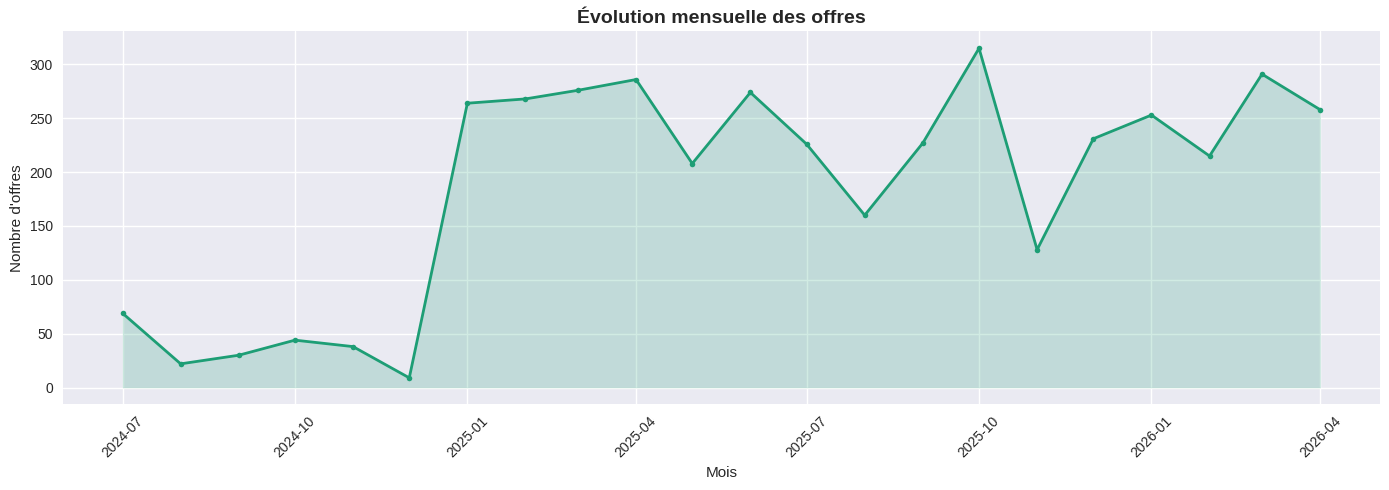

In [44]:
##4. Évolution mensuelle des offres

df['mois'] = pd.to_datetime(df['mois'], errors='coerce')
evolution = df.groupby('mois').size().reset_index(name='nb_offres')

plt.figure(figsize=(14, 5))
plt.plot(evolution['mois'], evolution['nb_offres'], color='#1D9E75', linewidth=2, marker='o', markersize=4)
plt.fill_between(evolution['mois'], evolution['nb_offres'], alpha=0.2, color='#1D9E75')
plt.xlabel("Mois")
plt.ylabel("Nombre d'offres")
plt.title("Évolution mensuelle des offres", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
print("=== KPIs PRINCIPAUX ===")
print(f"Total offres : {len(df)}")
print(f"Secteur dominant : {df['secteur'].value_counts().index[0]}")
print(f"Ville principale : {df['ville'].value_counts().index[0]}")
print(f"Contrat majoritaire : {df['contrat'].value_counts().index[0]}")

evolution = df.groupby('mois').size()
croissance = ((evolution.iloc[-1] - evolution.iloc[-2]) / evolution.iloc[-2] * 100).round(1)
print(f"Croissance dernière période : {croissance}%")

=== KPIs PRINCIPAUX ===
Total offres : 4212
Secteur dominant : ONG & Humanitaire
Ville principale : Dakar
Contrat majoritaire : CDD
Croissance dernière période : -11.3%


## Conclusions

- **Secteur dominant** : ONG & Humanitaire concentre le plus d'offres
- **Compétence clé** : Gestion de projet est la plus demandée
- **Géographie** : Dakar concentre 96% des offres géographique fort
- **Contrat** : CDD majoritaire à 69%
- **Expérience** : moyenne de 4 ans demandée

## Limites
- Données 2024 incomplètes (début juillet)
- 2026 incomplet (jusqu'en avril)
- Biais géographique lié aux sources en ligne
- Informatique exclu car tag générique non représentatif